# EU27 — Final Predictive Model: Target Achievement Analysis
## Fit-for-55 | 2030 Forecast | Cluster-Informed Shrinkage + Adaptive Window

This is the final integrated model. It incorporates every methodological decision made across the project:

| Stage | Decision |
|-------|----------|
| **Clustering** | k=4, reduced feature set (no GDP, population, composite gap) |
| **Trend fitting** | Adaptive window: post-2015 slope used when R²_post > R²_full, else full 2005–2024 |
| **Shrinkage** | Blended slope = w·individual + (1−w)·cluster_pooled, where w = R²_best |
| **Cluster prior** | Pooled normalised slope from matching window (full or post-2015) |
| **Forecast horizon** | 2030 with 90% prediction interval |
| **Three dimensions** | GHG emissions, Final Energy Consumption, Renewable Energy Share |

**Inputs:** `EU27_ESG_Panel_2005_2024.csv`, `EU27_cluster_labels_reduced.csv`  
**Outputs:** `final_forecast.csv`, `final_trajectories.png`, `final_heatmap.png`, `final_summary.png`


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── CONFIG ─────────────────────────────────────────────────────────────────────
PANEL_PATH    = "EU27_ESG_Panel_2005_2024.csv"
CLUSTER_PATH  = "EU27_cluster_labels_reduced.csv"
FORECAST_YEAR = 2030
BREAK_YEAR    = 2015      # structural break — post this year preferred if R² higher
CI_LEVEL      = 0.90
MIN_POST_OBS  = 4         # minimum observations needed to use post-window

DARK_BG  = "#0f1117"
PANEL_BG = "#1a1d2e"
CLUSTER_COLORS = {1: "#ff6b6b", 2: "#00d4ff", 3: "#7fff7f", 4: "#ffd700"}
CLUSTER_NAMES  = {
    1: "Large Emitters",
    2: "Heterogeneous Middle",
    3: "Green Transition Leaders",
    4: "Germany (Singleton)",
}
TARGETS = {
    "GHG": {"actual": "GHG_MtCO2eq",    "target": "GHG_FF55_Target_Mt",
            "label": "GHG (MtCO₂eq)",   "lower_is_better": True},
    "FEC": {"actual": "FEC_Mtoe",        "target": "FEC_FF55_Target_Mtoe",
            "label": "FEC (Mtoe)",       "lower_is_better": True},
    "RES": {"actual": "RES_Share_Pct",   "target": "RES_FF55_Target_Pct",
            "label": "RES Share (%)",    "lower_is_better": False},
}
PROJ_YEARS = np.arange(2005, 2031)
# ──────────────────────────────────────────────────────────────────────────────
print("Config loaded ✓")


Config loaded ✓


## 1. Load & Merge

In [5]:
df       = pd.read_csv(PANEL_PATH)
clusters = pd.read_csv(CLUSTER_PATH)
df       = df.merge(clusters[["Country_Code", "Cluster_k4"]], on="Country_Code")
df       = df.sort_values(["Country_Code", "Year"])

print(f"Panel: {df.shape}  |  Countries: {df['Country_Code'].nunique()}  |  Years: {df['Year'].min()}–{df['Year'].max()}")
print("\nCluster membership:")
for c, name in CLUSTER_NAMES.items():
    members = sorted(df[df["Cluster_k4"]==c]["Country_Code"].unique())
    print(f"  C{c} {name}: {', '.join(members)}")


Panel: (540, 19)  |  Countries: 27  |  Years: 2005–2024

Cluster membership:
  C1 Large Emitters: ES, FR, IT, PL
  C2 Heterogeneous Middle: BE, BG, CY, CZ, EE, GR, HR, HU, IE, LT, LU, MT, NL, RO, SI, SK
  C3 Green Transition Leaders: AT, DK, FI, LV, PT, SE
  C4 Germany (Singleton): DE


## 2. Model Functions

### 2a. Adaptive Window Selection
For each country-dimension, fit OLS on both the full series (2005–2024) and the  
post-break window (2015–2024). Use the post-2015 fit if it has higher R² *and*  
sufficient observations — this lets countries with recent acceleration be trusted  
on their own recent trajectory rather than pulled toward an outdated cluster prior.

### 2b. Cluster Pooled Prior
For each cluster-dimension-window combination, pool all member country series  
(normalised to 2005 or 2015 baseline) and fit a single OLS trend.  
The pooled slope is rescaled back to each country's unit scale for blending.

### 2c. Shrinkage Blending
```
w              = R²_best   (reliability of the chosen individual window)
blended_slope  = w · individual_slope + (1−w) · cluster_slope_rescaled
```
Low R² → lean on cluster. High R² → trust own trend.


In [6]:
def fit_ols(years, y):
    """Fit OLS, return (slope, intercept, r2). Floor r2 at 0."""
    if len(y) < 3:
        return None, None, 0.0
    X  = years.reshape(-1, 1)
    lr = LinearRegression().fit(X, y)
    yp = lr.predict(X)
    return lr.coef_[0], lr.intercept_, max(r2_score(y, yp), 0.0)


def build_individual_fits(df, break_year=BREAK_YEAR, min_post=MIN_POST_OBS):
    fits = {}
    for code, grp in df.groupby("Country_Code"):
        grp     = grp.sort_values("Year")
        cluster = grp["Cluster_k4"].iloc[0]
        for dim, cfg in TARGETS.items():
            yrs_f = grp["Year"].values.astype(float)
            y_f   = grp[cfg["actual"]].values
            s_f, i_f, r2_f = fit_ols(yrs_f, y_f)

            grp_p = grp[grp["Year"] >= break_year]
            yrs_p = grp_p["Year"].values.astype(float)
            y_p   = grp_p[cfg["actual"]].values
            s_p, i_p, r2_p = fit_ols(yrs_p, y_p)

            use_post  = (r2_p > r2_f) and (len(y_p) >= min_post)
            slope     = s_p if use_post else s_f
            intercept = i_p if use_post else i_f
            r2_best   = r2_p if use_post else r2_f

            fits[(code, dim)] = {
                "slope": slope, "intercept": intercept,
                "r2_full": r2_f, "r2_post": r2_p, "r2_best": r2_best,
                "use_post": use_post, "cluster": cluster,
                "target": grp[cfg["target"]].iloc[0],
            }
    return fits


def build_cluster_fits(df, break_year=BREAK_YEAR):
    cfits = {}
    for cluster_id in sorted(df["Cluster_k4"].unique()):
        cdf = df[df["Cluster_k4"] == cluster_id]
        for dim, cfg in TARGETS.items():
            for window, yr_start in [("full", 2005), ("post", break_year)]:
                rows = []
                for code, grp in cdf.groupby("Country_Code"):
                    grp = grp[grp["Year"] >= yr_start].sort_values("Year")
                    if len(grp) < 3: continue
                    base = grp[cfg["actual"]].iloc[0]
                    if base == 0: continue
                    for _, r in grp.iterrows():
                        rows.append({"Year": r["Year"],
                                     "val_norm": r[cfg["actual"]] / base})
                pool = pd.DataFrame(rows)
                X = pool["Year"].values.reshape(-1, 1)
                y = pool["val_norm"].values
                lr = LinearRegression().fit(X, y)
                cfits[(cluster_id, dim, window)] = {
                    "slope_norm": lr.coef_[0],
                    "intercept_norm": lr.intercept_,
                    "r2": max(r2_score(y, lr.predict(X)), 0.0),
                }
    return cfits


def project_country(code, grp, ind_fits, cluster_fits):
    cluster   = grp["Cluster_k4"].iloc[0]
    country   = grp["Country_Name"].iloc[0]
    y_all     = {}   # store for CI calc

    row = {"Country_Code": code, "Country": country,
           "Cluster": cluster, "Cluster_Name": CLUSTER_NAMES[cluster]}

    for dim, cfg in TARGETS.items():
        y        = grp[cfg["actual"]].values
        base_val = y[0]
        tgt      = grp[cfg["target"]].iloc[0]
        ind      = ind_fits[(code, dim)]
        window   = "post" if ind["use_post"] else "full"
        pool     = cluster_fits[(cluster, dim, window)]

        cluster_slope_raw = pool["slope_norm"] * base_val
        w          = ind["r2_best"]
        bld_slope  = w * ind["slope"] + (1 - w) * cluster_slope_raw
        bld_interc = np.mean(y) - bld_slope * np.mean(grp["Year"].values.astype(float))
        proj       = bld_interc + bld_slope * FORECAST_YEAR

        # 90% PI
        yrs   = grp["Year"].values.astype(float)
        resid = y - (bld_interc + bld_slope * yrs)
        s     = np.std(resid, ddof=2)
        n     = len(y)
        t_crit = stats.t.ppf((1 + CI_LEVEL) / 2, df=max(n - 2, 1))
        margin = t_crit * s * np.sqrt(1 + 1 / n)

        lib      = cfg["lower_is_better"]
        on_track = proj <= tgt if lib else proj >= tgt

        row.update({
            f"{dim}_proj":     round(proj, 3),
            f"{dim}_ci_lo":    round(proj - margin, 3),
            f"{dim}_ci_hi":    round(proj + margin, 3),
            f"{dim}_target":   round(tgt, 3),
            f"{dim}_gap":      round(proj - tgt, 3),
            f"{dim}_on_track": on_track,
            f"{dim}_w":        round(w, 3),
            f"{dim}_r2_full":  round(ind["r2_full"], 3),
            f"{dim}_r2_post":  round(ind["r2_post"], 3),
            f"{dim}_window":   window,
            f"{dim}_slope":    round(bld_slope, 4),
            f"{dim}_interc":   round(bld_interc, 4),
        })
        y_all[dim] = (y, bld_slope, bld_interc)

    return row, y_all


print("Model functions defined ✓")


Model functions defined ✓


## 3. Run Final Model

In [7]:
ind_fits     = build_individual_fits(df)
cluster_fits = build_cluster_fits(df)

records = []
for code, grp in df.groupby("Country_Code"):
    grp = grp.sort_values("Year")
    row, _ = project_country(code, grp, ind_fits, cluster_fits)
    records.append(row)

results = pd.DataFrame(records).sort_values(["Cluster", "Country"]).reset_index(drop=True)
print(f"Model complete — {len(results)} countries\n")

# On-track summary
for dim in ["GHG", "FEC", "RES"]:
    n = results[f"{dim}_on_track"].sum()
    print(f"  {dim}: {n}/27 on track  |  "
          f"avg gap: {results[f'{dim}_gap'].mean():.2f}")


Model complete — 27 countries

  GHG: 7/27 on track  |  avg gap: 13.34
  FEC: 6/27 on track  |  avg gap: 1.84
  RES: 8/27 on track  |  avg gap: -0.86


## 4. Window Selection Audit

Which countries used post-2015 vs full-series window?  
This is a key transparency table for your thesis — it shows where the model  
departed from a naive full-history OLS and why.


In [8]:
audit_rows = []
for code, grp in df.groupby("Country_Code"):
    grp = grp.sort_values("Year")
    country = grp["Country_Name"].iloc[0]
    cluster = grp["Cluster_k4"].iloc[0]
    for dim in ["GHG", "FEC", "RES"]:
        ind = ind_fits[(code, dim)]
        audit_rows.append({
            "Country":     country,
            "Cluster":     CLUSTER_NAMES[cluster],
            "Dimension":   dim,
            "Window Used": "Post-2015" if ind["use_post"] else "Full (2005–)",
            "R² Full":     round(ind["r2_full"], 3),
            "R² Post-2015":round(ind["r2_post"], 3),
            "R² Best":     round(ind["r2_best"], 3),
        })

audit = pd.DataFrame(audit_rows)
post_count = (audit["Window Used"] == "Post-2015").sum()
print(f"Post-2015 window used: {post_count}/{len(audit)} series ({post_count/len(audit)*100:.0f}%)")
print(f"Full window used     : {len(audit)-post_count}/{len(audit)} series\n")

audit.pivot_table(index="Country", columns="Dimension", values="Window Used", aggfunc="first") \
     .style.applymap(lambda v: "background-color: #1a2d3d; color: #00d4ff" 
                     if v == "Post-2015" else "background-color: #1a1a1a; color: #888")


Post-2015 window used: 23/81 series (28%)
Full window used     : 58/81 series



Dimension,FEC,GHG,RES
Country,,,
Austria,Post-2015,Full (2005–),Full (2005–)
Belgium,Post-2015,Full (2005–),Full (2005–)
Bulgaria,Post-2015,Full (2005–),Full (2005–)
Croatia,Post-2015,Full (2005–),Full (2005–)
Cyprus,Post-2015,Post-2015,Post-2015
Czechia,Full (2005–),Full (2005–),Full (2005–)
Denmark,Full (2005–),Full (2005–),Full (2005–)
Estonia,Full (2005–),Post-2015,Full (2005–)
Finland,Post-2015,Full (2005–),Full (2005–)


## 5. Results Table

In [9]:
def style_bool(v):
    if v is True:  return "background-color: #1a3d1a; color: #7fff7f"
    if v is False: return "background-color: #3d1a1a; color: #ff6b6b"
    return ""

def style_w(v):
    if   v >= 0.75: return "color: #7fff7f"
    elif v >= 0.50: return "color: #ffd700"
    else:           return "color: #ff6b6b"

cols = ["Country", "Cluster_Name",
        "GHG_proj", "GHG_target", "GHG_gap", "GHG_on_track", "GHG_w", "GHG_window",
        "FEC_proj", "FEC_target", "FEC_gap", "FEC_on_track", "FEC_w", "FEC_window",
        "RES_proj", "RES_target", "RES_gap", "RES_on_track", "RES_w", "RES_window"]

results[cols].style \
    .applymap(style_bool,  subset=["GHG_on_track","FEC_on_track","RES_on_track"]) \
    .applymap(style_w,     subset=["GHG_w","FEC_w","RES_w"]) \
    .format(precision=2) \
    .set_caption("w = shrinkage weight (R²). Green w ≥ 0.75 · Yellow 0.50–0.75 · Red < 0.50")


,Country,Cluster_Name,GHG_proj,GHG_target,GHG_gap,GHG_on_track,GHG_w,GHG_window,FEC_proj,FEC_target,FEC_gap,FEC_on_track,FEC_w,FEC_window,RES_proj,RES_target,RES_gap,RES_on_track,RES_w,RES_window
0,France,Large Emitters,347.44,238.91,108.54,False,0.94,full,129.31,106.84,22.47,False,0.73,full,29.54,33.00,-3.46,False,0.97,post
1,Italy,Large Emitters,296.12,227.09,69.03,False,0.91,full,98.00,101.96,-3.96,True,0.85,full,25.33,39.40,-14.07,False,0.88,full
2,Poland,Large Emitters,334.36,231.06,103.30,False,0.55,full,73.22,58.50,14.71,False,0.72,full,21.16,29.80,-8.64,False,0.95,full
3,Spain,Large Emitters,226.95,132.55,94.40,False,0.87,full,76.12,71.70,4.42,False,0.55,full,28.59,48.00,-19.41,False,0.96,full
4,Belgium,Heterogeneous Middle,99.63,63.26,36.38,False,0.90,full,30.55,29.91,0.63,False,0.63,post,18.84,21.70,-2.86,False,0.97,full
5,Bulgaria,Heterogeneous Middle,48.01,45.34,2.67,False,0.56,full,9.52,8.79,0.72,False,0.14,post,37.25,35.00,2.25,True,0.88,full
6,Croatia,Heterogeneous Middle,22.29,14.77,7.52,False,0.53,full,7.38,6.61,0.77,False,0.50,post,111.03,42.50,68.53,True,0.64,full
7,Cyprus,Heterogeneous Middle,7.97,2.51,5.46,False,0.44,post,1.81,1.79,0.02,False,0.10,post,31.84,33.00,-1.16,False,0.95,post
8,Czechia,Heterogeneous Middle,98.16,89.81,8.35,False,0.89,full,23.36,20.40,2.96,False,0.25,full,25.70,30.00,-4.30,False,0.96,full
9,Estonia,Heterogeneous Middle,3.22,20.52,-17.30,True,0.76,post,2.79,2.60,0.19,False,0.20,full,56.50,65.00,-8.50,False,0.94,full


## 6. Cluster-Level Summary

In [10]:
summary = results.groupby(["Cluster","Cluster_Name"]).agg(
    N              = ("Country_Code","count"),
    GHG_on_track   = ("GHG_on_track","sum"),
    FEC_on_track   = ("FEC_on_track","sum"),
    RES_on_track   = ("RES_on_track","sum"),
    GHG_avg_gap    = ("GHG_gap","mean"),
    FEC_avg_gap    = ("FEC_gap","mean"),
    RES_avg_gap    = ("RES_gap","mean"),
    GHG_avg_w      = ("GHG_w","mean"),
    FEC_avg_w      = ("FEC_w","mean"),
    RES_avg_w      = ("RES_w","mean"),
).reset_index()

for dim in ["GHG","FEC","RES"]:
    summary[f"{dim}_%"] = (summary[f"{dim}_on_track"] / summary["N"] * 100) \
                           .round(0).astype(int).astype(str) + "%"

print(summary[["Cluster_Name","N",
               "GHG_on_track","GHG_%","GHG_avg_gap",
               "FEC_on_track","FEC_%","FEC_avg_gap",
               "RES_on_track","RES_%","RES_avg_gap"]].to_string(index=False))


            Cluster_Name  N  GHG_on_track GHG_%  GHG_avg_gap  FEC_on_track FEC_%  FEC_avg_gap  RES_on_track RES_%  RES_avg_gap
          Large Emitters  4             0    0%    93.818250             1   25%     9.412000             0    0%   -11.396000
    Heterogeneous Middle 16             4   25%     3.559375             3   19%     0.619563             7   44%     4.548813
Green Transition Leaders  6             2   33%     8.027333             2   33%     0.301833             1   17%    -5.925500
     Germany (Singleton)  1             1  100%  -120.128000             0    0%     0.288000             0    0%   -14.831000


## 7. Final Trajectory Plot

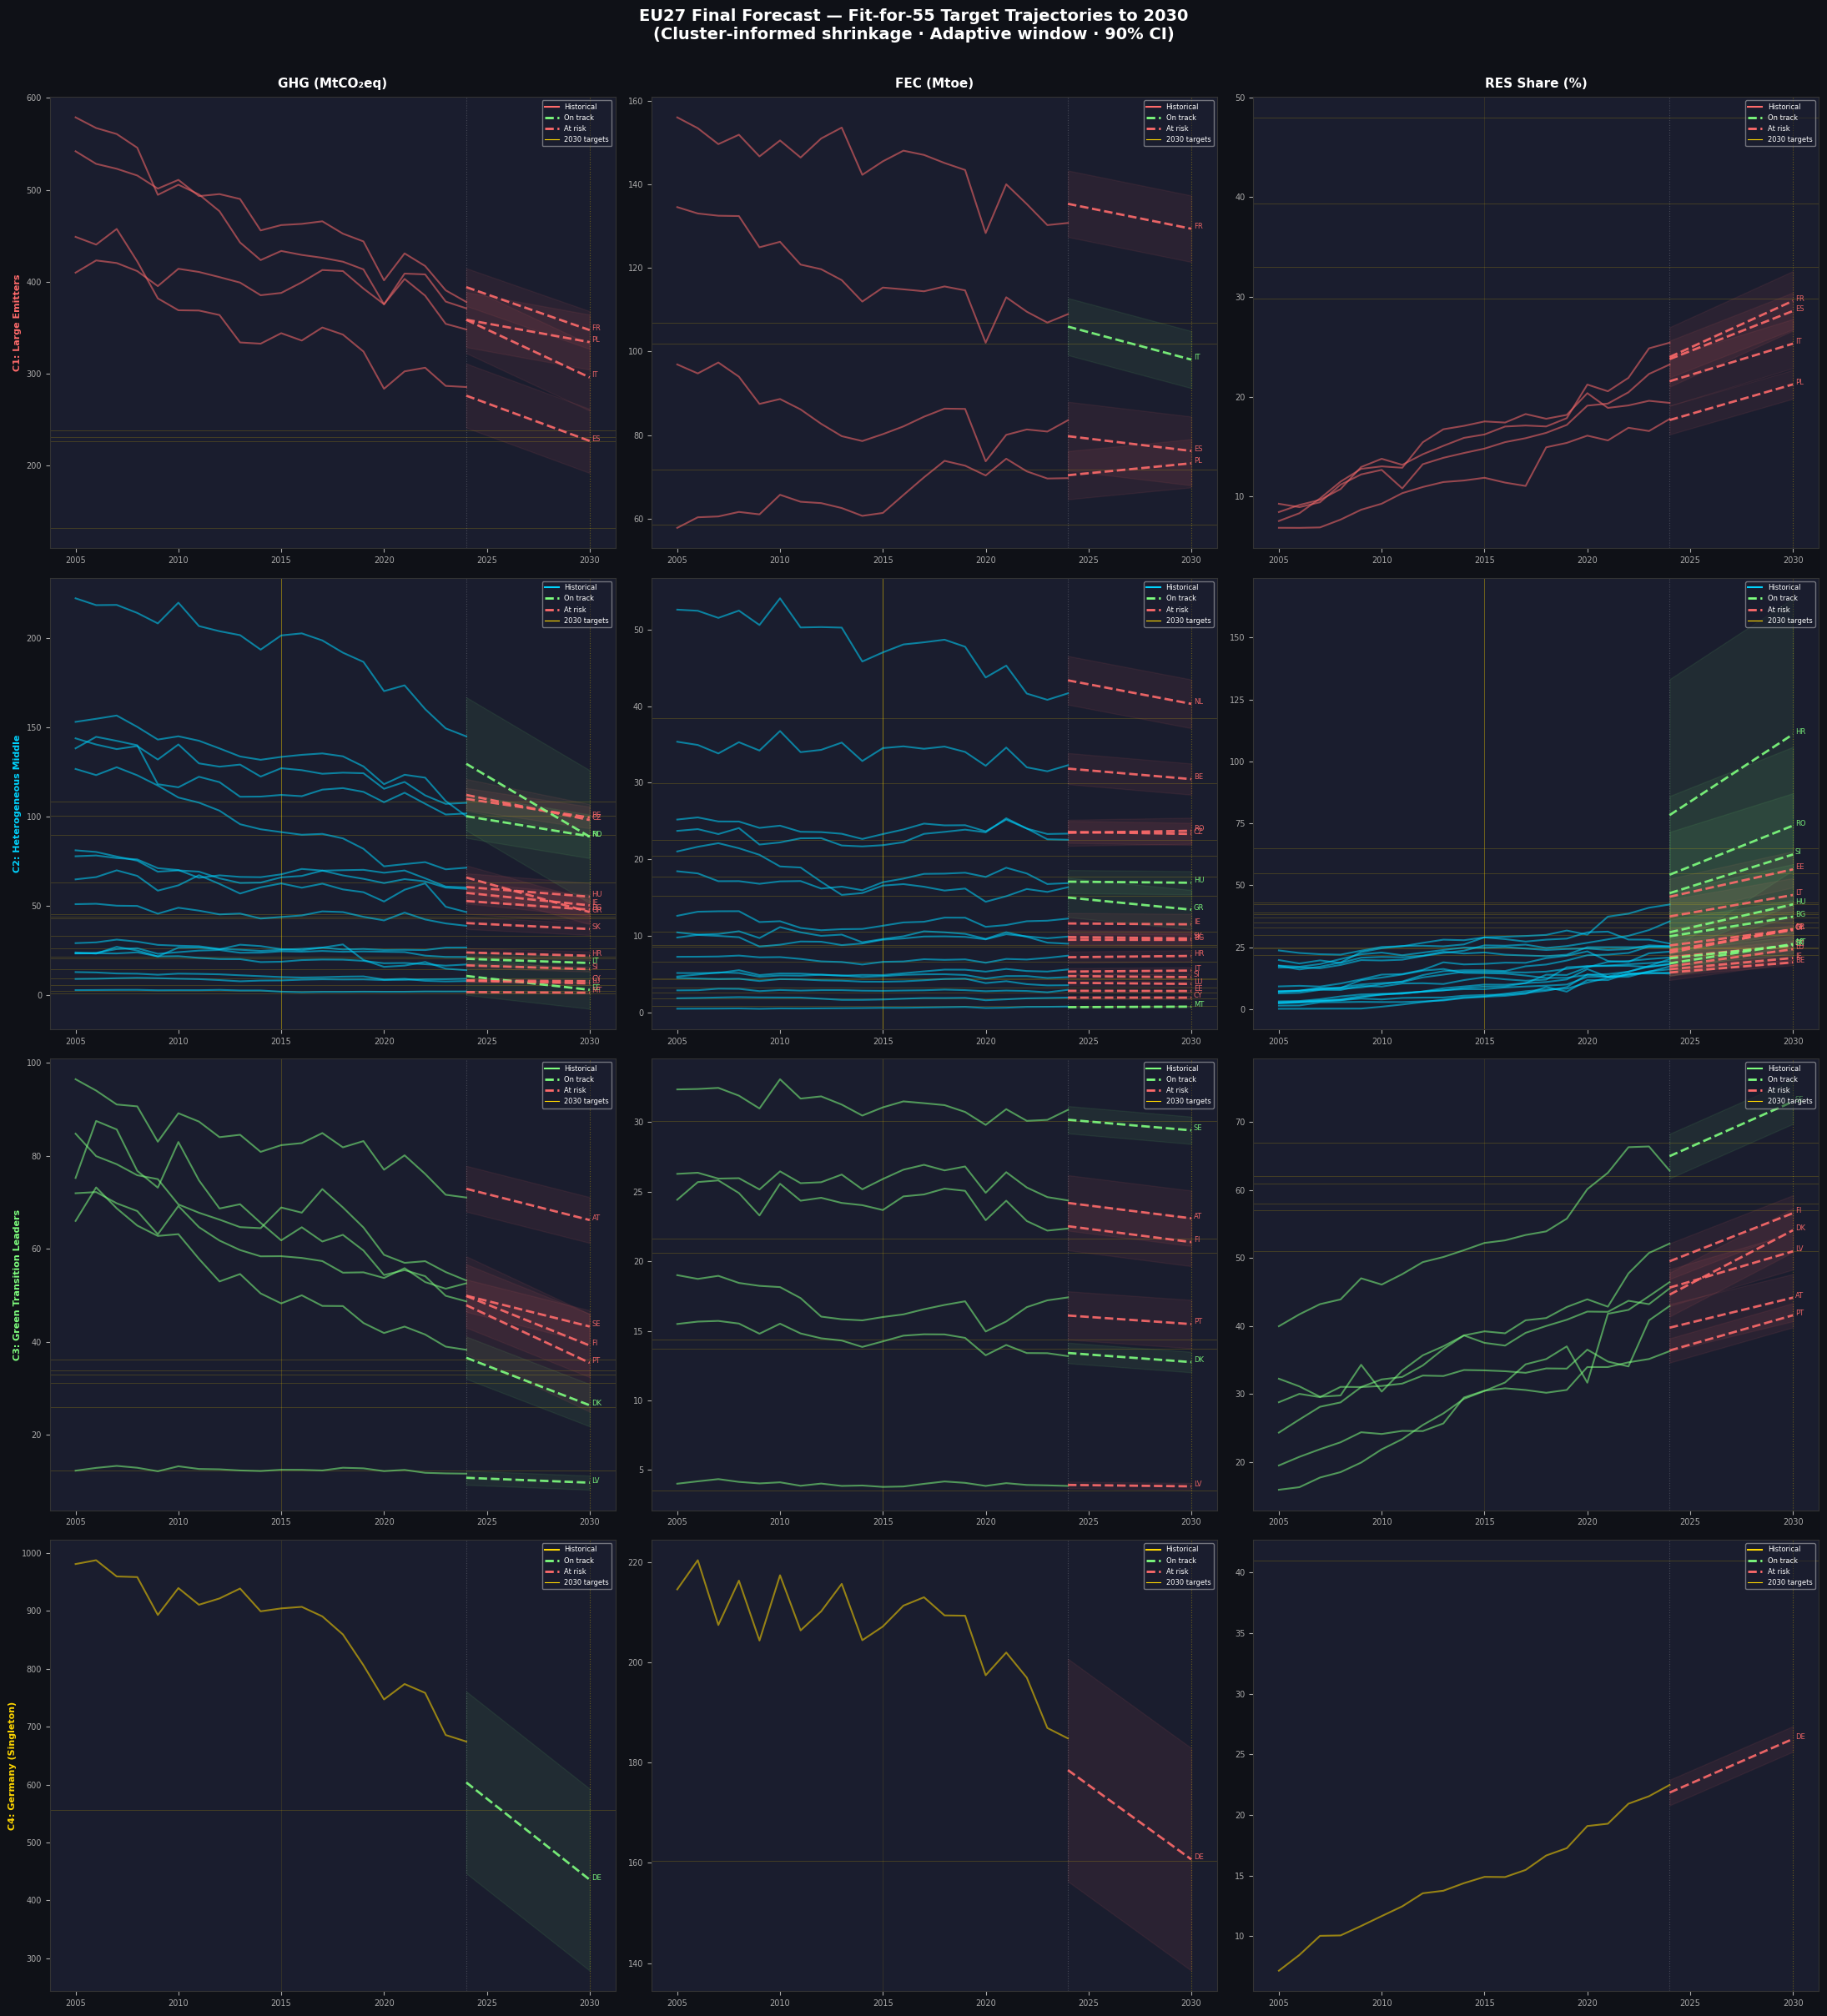

Saved → final_trajectories.png


In [11]:
fig, axes = plt.subplots(4, 3, figsize=(22, 24))
fig.patch.set_facecolor(DARK_BG)

for ci, (cluster_id, cluster_name) in enumerate(CLUSTER_NAMES.items()):
    c_members = df[df["Cluster_k4"]==cluster_id]["Country_Code"].unique()
    c_color   = CLUSTER_COLORS[cluster_id]

    for di, (dim, cfg) in enumerate(TARGETS.items()):
        ax = axes[ci][di]
        ax.set_facecolor(PANEL_BG)

        for code in sorted(c_members):
            grp = df[df["Country_Code"]==code].sort_values("Year")
            yrs = grp["Year"].values.astype(float)
            y   = grp[cfg["actual"]].values
            tgt = grp[cfg["target"]].iloc[0]

            # Retrieve blended params
            r = results[results["Country_Code"]==code].iloc[0]
            slope  = r[f"{dim}_slope"]
            interc = r[f"{dim}_interc"]
            proj_vals = interc + slope * PROJ_YEARS

            # CI
            resid  = y - (interc + slope * yrs)
            s      = np.std(resid, ddof=2); n = len(y)
            t_crit = stats.t.ppf((1+CI_LEVEL)/2, df=max(n-2,1))
            margin = t_crit * s * np.sqrt(1 + 1/n)

            on_track   = r[f"{dim}_on_track"]
            use_post   = r[f"{dim}_window"] == "post"
            line_color = "#7fff7f" if on_track else "#ff6b6b"

            # Historical
            ax.plot(yrs, y, color=c_color, lw=1.5, alpha=0.55, zorder=3)

            # Projection
            mask = PROJ_YEARS >= 2024
            ax.plot(PROJ_YEARS[mask], proj_vals[mask],
                    color=line_color, lw=2, linestyle="--", alpha=0.9, zorder=4)
            ax.fill_between(PROJ_YEARS[mask],
                            proj_vals[mask]-margin, proj_vals[mask]+margin,
                            color=line_color, alpha=0.07)

            # Post-2015 window marker
            if use_post:
                ax.axvline(2015, color="#ffd700", lw=0.5, alpha=0.15)

            # Country label at 2030
            ax.annotate(code, (2030, proj_vals[-1]),
                        fontsize=6, color=line_color, alpha=0.9,
                        xytext=(2,0), textcoords="offset points")

        # Target lines (individual, semi-transparent)
        for tgt_val in df[df["Cluster_k4"]==cluster_id][cfg["target"]].unique():
            ax.axhline(tgt_val, color="#ffd700", lw=0.5, alpha=0.25)

        ax.axvline(2024, color="white", lw=0.8, alpha=0.2, linestyle=":")
        ax.axvline(2030, color="#ffd700", lw=0.8, alpha=0.35, linestyle=":")

        if ci == 0:
            ax.set_title(cfg["label"], color="white", fontsize=11,
                         fontweight="bold", pad=8)
        if di == 0:
            ax.set_ylabel(f"C{cluster_id}: {cluster_name}",
                          color=c_color, fontsize=8, fontweight="bold")

        ax.tick_params(colors="#aaa", labelsize=7)
        ax.spines[:].set_edgecolor("#333")

        legend_els = [
            Line2D([0],[0], color=c_color,    lw=1.5, label="Historical"),
            Line2D([0],[0], color="#7fff7f",  lw=2, linestyle="--", label="On track"),
            Line2D([0],[0], color="#ff6b6b",  lw=2, linestyle="--", label="At risk"),
            Line2D([0],[0], color="#ffd700",  lw=0.8, label="2030 targets"),
        ]
        ax.legend(handles=legend_els, fontsize=6, facecolor=PANEL_BG,
                  labelcolor="white", loc="upper right", framealpha=0.5)

plt.suptitle("EU27 Final Forecast — Fit-for-55 Target Trajectories to 2030\n"
             "(Cluster-informed shrinkage · Adaptive window · 90% CI)",
             color="white", fontsize=14, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig("final_trajectories.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("Saved → final_trajectories.png")


## 8. Gap Heatmap — All Countries × All Dimensions

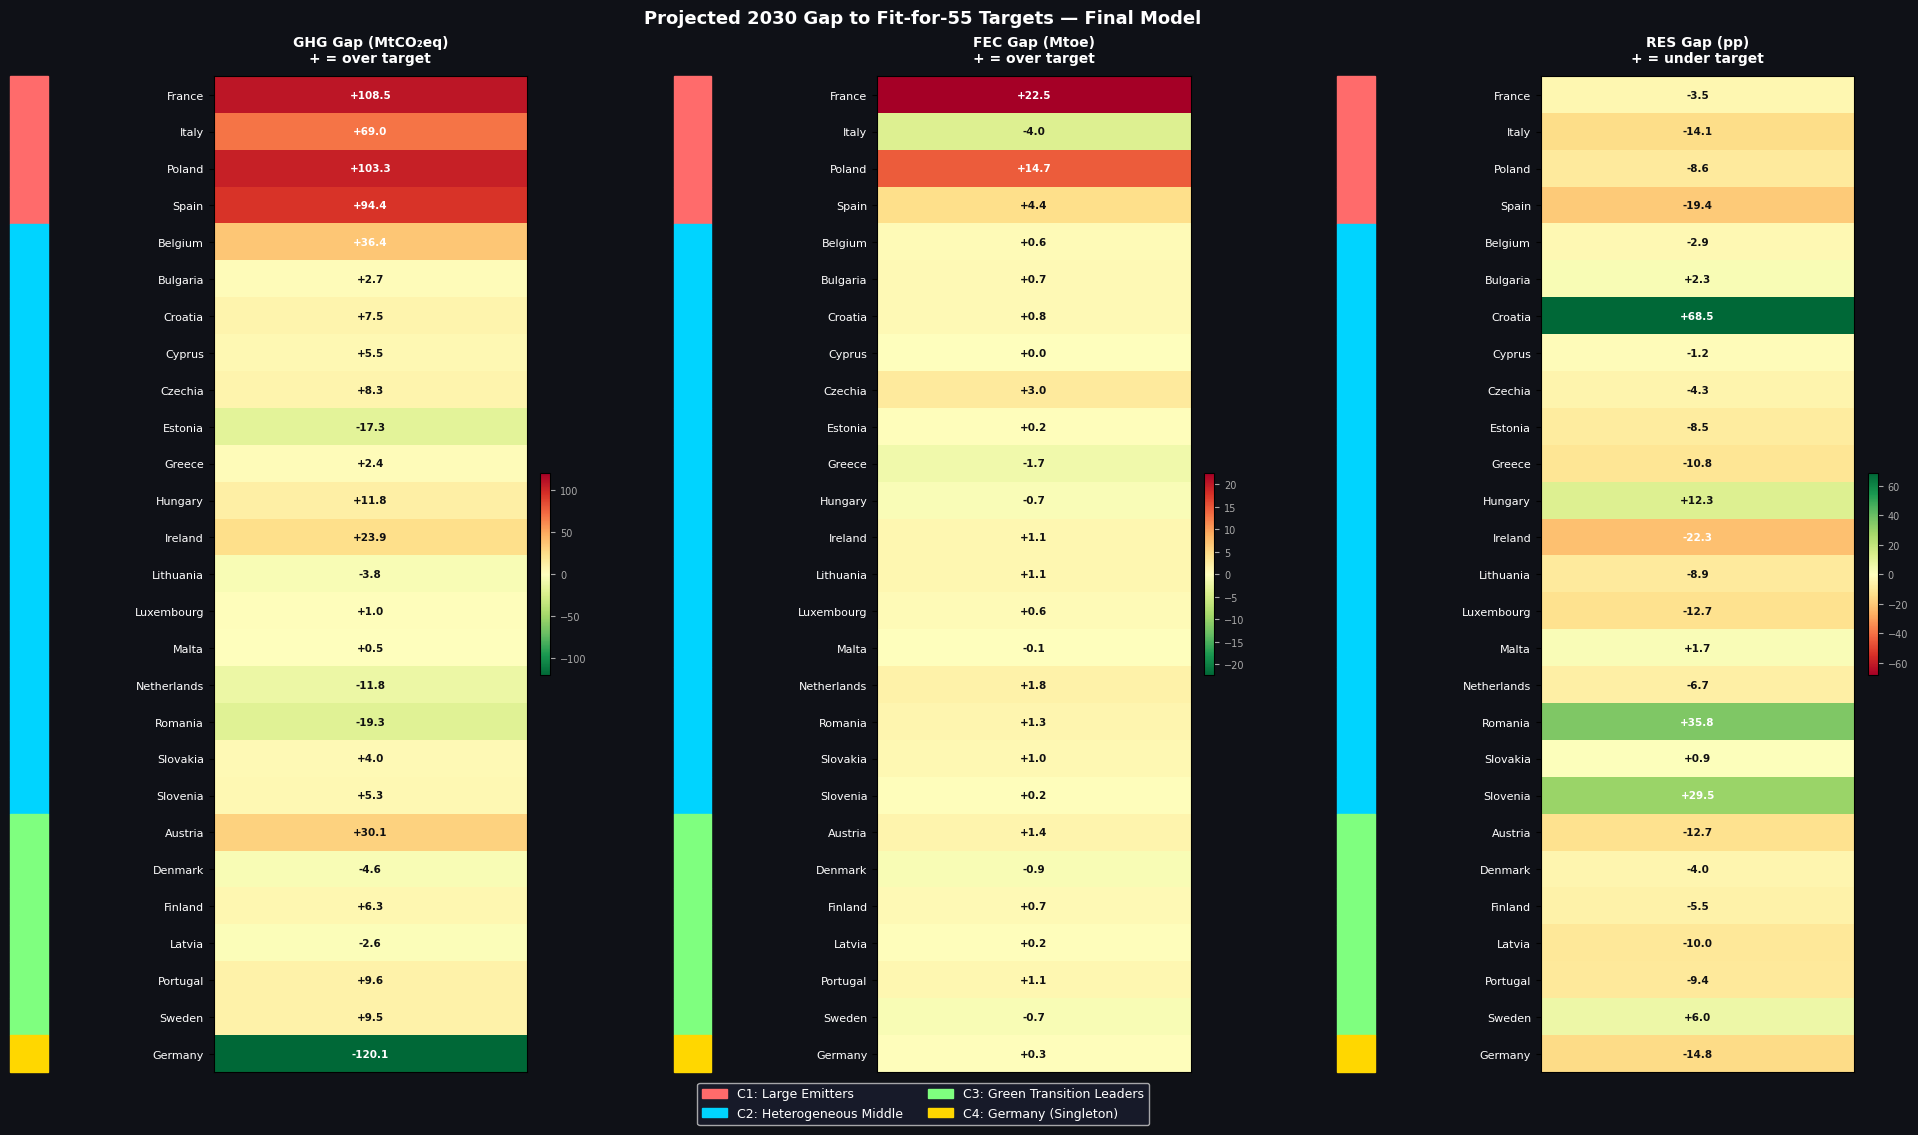

Saved → final_heatmap.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 11))
fig.patch.set_facecolor(DARK_BG)

results_sorted = results.sort_values(["Cluster","Country"])
countries_ord  = results_sorted["Country"].values
cluster_labels = results_sorted["Cluster"].values

dims_hm = [
    ("GHG_gap", "GHG Gap (MtCO₂eq)\n+ = over target", True),
    ("FEC_gap", "FEC Gap (Mtoe)\n+ = over target",     True),
    ("RES_gap", "RES Gap (pp)\n+ = under target",      False),
]

for ax, (col, title, lower_bad) in zip(axes, dims_hm):
    ax.set_facecolor(PANEL_BG)
    vals = results_sorted[col].values.astype(float).reshape(-1, 1)
    vmax = np.abs(vals).max()
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cmap = "RdYlGn_r" if lower_bad else "RdYlGn"
    im   = ax.imshow(vals, aspect="auto", cmap=cmap, norm=norm)

    ax.set_xticks([])
    ax.set_yticks(range(len(countries_ord)))
    ax.set_yticklabels(countries_ord, fontsize=8, color="white")

    # Cluster stripe
    for i, cl in enumerate(cluster_labels):
        ax.add_patch(plt.Rectangle((-1.15, i-0.5), 0.12, 1,
                             color=CLUSTER_COLORS[cl], clip_on=False))

    # Value labels — dark text on light cells, white on dark
    vmin_val, vmax_val = -vmax, vmax
    for i, v in enumerate(vals.flatten()):
        nv = (v - vmin_val) / (vmax_val - vmin_val) if vmax_val != vmin_val else 0.5
        txt_color = "#111111" if 0.35 < nv < 0.65 else "white"
        ax.text(0, i, f"{v:+.1f}", ha="center", va="center",
                fontsize=7.5, color=txt_color, fontweight="bold")

    ax.set_title(title, color="white", fontsize=10, fontweight="bold", pad=10)
    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    cbar.ax.tick_params(colors="#aaa", labelsize=7)

legend_patches = [Patch(color=CLUSTER_COLORS[c], label=f"C{c}: {CLUSTER_NAMES[c]}")
                  for c in CLUSTER_NAMES]
fig.legend(handles=legend_patches, loc="lower center", ncol=2,
           facecolor=PANEL_BG, labelcolor="white", fontsize=9,
           bbox_to_anchor=(0.5, -0.04))

plt.suptitle("Projected 2030 Gap to Fit-for-55 Targets — Final Model",
             color="white", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("final_heatmap.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("Saved → final_heatmap.png")


## 9. Executive Scorecard

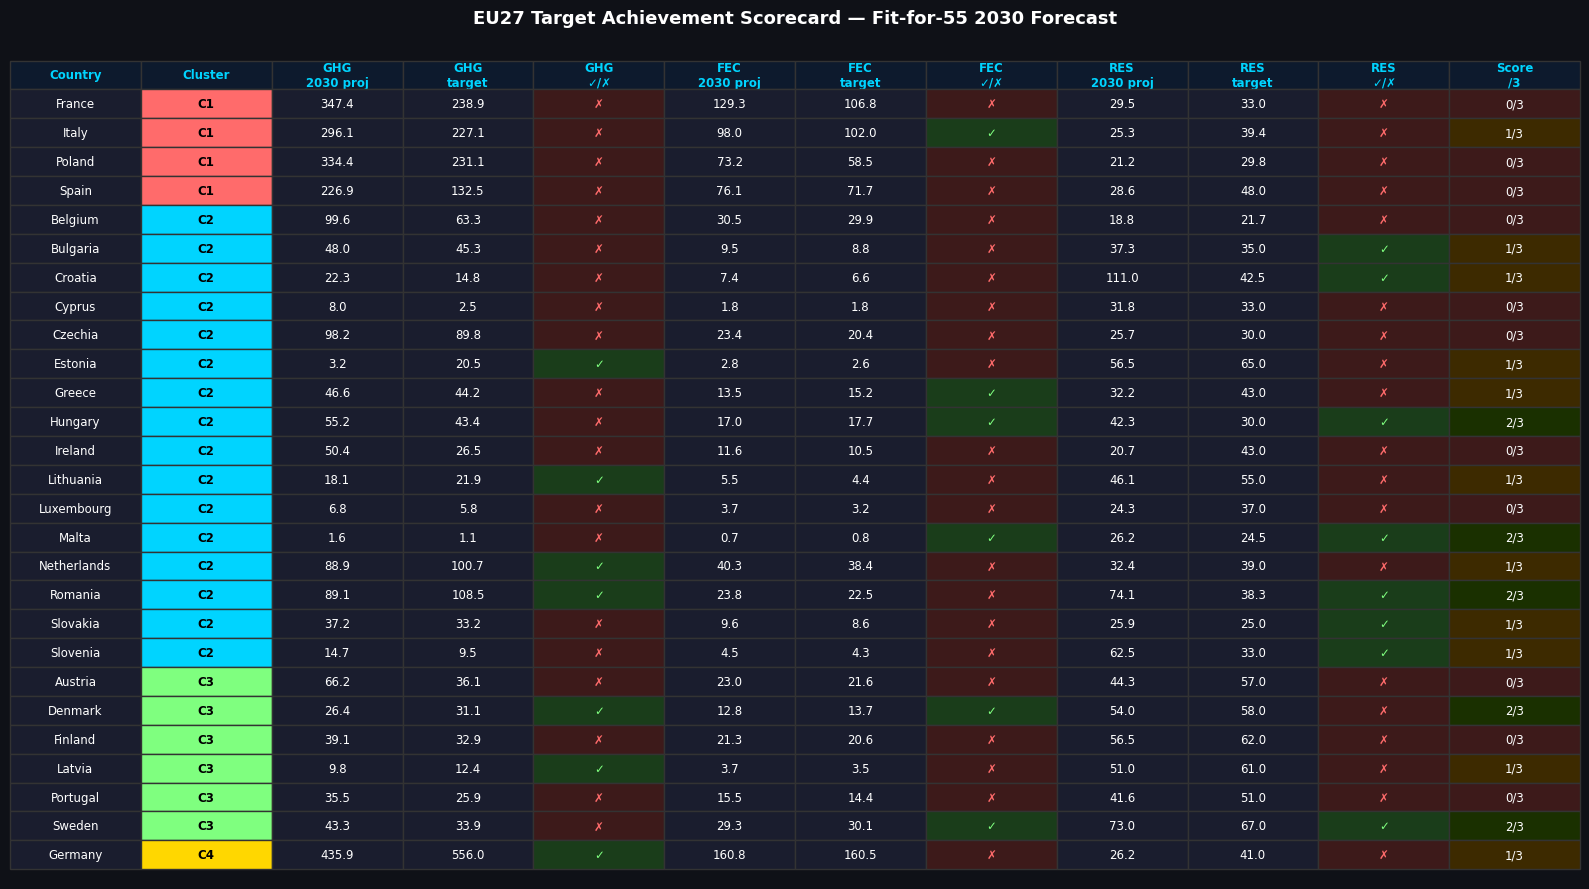

Saved → final_summary.png


In [13]:
fig, ax = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)
ax.axis("off")

results_s = results.sort_values(["Cluster","Country"])

col_labels = ["Country", "Cluster", "GHG\n2030 proj", "GHG\ntarget", "GHG\n✓/✗",
              "FEC\n2030 proj", "FEC\ntarget", "FEC\n✓/✗",
              "RES\n2030 proj", "RES\ntarget", "RES\n✓/✗", "Score\n/3"]

table_data = []
for _, r in results_s.iterrows():
    score = int(r["GHG_on_track"]) + int(r["FEC_on_track"]) + int(r["RES_on_track"])
    table_data.append([
        r["Country"], f"C{r['Cluster']}",
        f"{r['GHG_proj']:.1f}", f"{r['GHG_target']:.1f}", "✓" if r["GHG_on_track"] else "✗",
        f"{r['FEC_proj']:.1f}", f"{r['FEC_target']:.1f}", "✓" if r["FEC_on_track"] else "✗",
        f"{r['RES_proj']:.1f}", f"{r['RES_target']:.1f}", "✓" if r["RES_on_track"] else "✗",
        f"{score}/3",
    ])

tbl = ax.table(cellText=table_data, colLabels=col_labels,
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.45)

# Style cells
for (row, col), cell in tbl.get_celld().items():
    cell.set_facecolor(PANEL_BG)
    cell.set_edgecolor("#333")
    cell.set_text_props(color="white")

    if row == 0:
        cell.set_facecolor("#0d1a2d")
        cell.set_text_props(color="#00d4ff", fontweight="bold")

    if row > 0:
        r_data = results_s.iloc[row - 1]
        # Cluster colour in col 1
        if col == 1:
            cell.set_facecolor(CLUSTER_COLORS[r_data["Cluster"]])
            cell.set_text_props(color="black", fontweight="bold")
        # On-track columns
        for ci_check, dim in [(4,"GHG"),(7,"FEC"),(10,"RES")]:
            if col == ci_check:
                on = r_data[f"{dim}_on_track"]
                cell.set_facecolor("#1a3d1a" if on else "#3d1a1a")
                cell.set_text_props(color="#7fff7f" if on else "#ff6b6b", fontweight="bold")
        # Score column
        if col == 11:
            score_val = int(r_data["GHG_on_track"]) + int(r_data["FEC_on_track"]) + int(r_data["RES_on_track"])
            sc = ["#3d1a1a","#3d2a00","#1a3000","#1a3d1a"][score_val]
            cell.set_facecolor(sc)

ax.set_title("EU27 Target Achievement Scorecard — Fit-for-55 2030 Forecast",
             color="white", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("final_summary.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("Saved → final_summary.png")


## 10. Export

In [14]:
export_cols = [
    "Country_Code","Country","Cluster","Cluster_Name",
    "GHG_proj","GHG_ci_lo","GHG_ci_hi","GHG_target","GHG_gap","GHG_on_track",
    "GHG_r2_full","GHG_r2_post","GHG_w","GHG_window",
    "FEC_proj","FEC_ci_lo","FEC_ci_hi","FEC_target","FEC_gap","FEC_on_track",
    "FEC_r2_full","FEC_r2_post","FEC_w","FEC_window",
    "RES_proj","RES_ci_lo","RES_ci_hi","RES_target","RES_gap","RES_on_track",
    "RES_r2_full","RES_r2_post","RES_w","RES_window",
]
results[export_cols].to_csv("final_forecast.csv", index=False)
print("Saved → final_forecast.csv")
results[export_cols]


Saved → final_forecast.csv


,Country_Code,Country,Cluster,Cluster_Name,GHG_proj,GHG_ci_lo,GHG_ci_hi,GHG_target,GHG_gap,GHG_on_track,...,RES_proj,RES_ci_lo,RES_ci_hi,RES_target,RES_gap,RES_on_track,RES_r2_full,RES_r2_post,RES_w,RES_window
0,FR,France,1,Large Emitters,347.443,326.873,368.013,238.905,108.538,False,...,29.541,26.557,32.524,33.0,-3.459,False,0.958,0.967,0.967,post
1,IT,Italy,1,Large Emitters,296.124,259.866,332.382,227.093,69.031,False,...,25.326,22.868,27.785,39.4,-14.074,False,0.883,0.620,0.883,full
2,PL,Poland,1,Large Emitters,334.355,304.480,364.229,231.055,103.300,False,...,21.162,19.715,22.609,29.8,-8.638,False,0.952,0.837,0.952,full
3,ES,Spain,1,Large Emitters,226.950,192.070,261.830,132.546,94.404,False,...,28.587,26.740,30.435,48.0,-19.413,False,0.957,0.904,0.957,full
4,BE,Belgium,2,Heterogeneous Middle,99.634,93.577,105.691,63.258,36.376,False,...,18.844,17.640,20.048,21.7,-2.856,False,0.973,0.928,0.973,full
5,BG,Bulgaria,2,Heterogeneous Middle,48.012,40.927,55.097,45.340,2.672,False,...,37.252,30.514,43.989,35.0,2.252,True,0.883,0.437,0.883,full
6,HR,Croatia,2,Heterogeneous Middle,22.290,19.841,24.739,14.774,7.516,False,...,111.030,56.131,165.928,42.5,68.530,True,0.636,0.009,0.636,full
7,CY,Cyprus,2,Heterogeneous Middle,7.974,7.042,8.906,2.512,5.463,False,...,31.840,26.980,36.701,33.0,-1.160,False,0.949,0.952,0.952,post
8,CZ,Czechia,2,Heterogeneous Middle,98.160,89.252,107.068,89.812,8.348,False,...,25.699,23.721,27.677,30.0,-4.301,False,0.964,0.933,0.964,full
9,EE,Estonia,2,Heterogeneous Middle,3.224,-7.423,13.870,20.524,-17.300,True,...,56.499,49.184,63.814,65.0,-8.501,False,0.936,0.854,0.936,full
